In [1]:
%%bash

file_name="dataset.zip"
actual_dir_name="PlantDoc-Object-Detection-Dataset-master"
dataset_url="https://github.com/pratikkayal/PlantDoc-Object-Detection-Dataset/archive/refs/heads/master.zip"

# Download dataset from the git repo
curl -L -o "$file_name" "$dataset_url"

# Unzip the dataset zip file
unzip -q "$file_name"

# Since the zip is of no use now, remove it
rm "$file_name"

# move train and test folder to project home
mv "${actual_dir_name}/TRAIN" .
mv "${actual_dir_name}/TEST" .

# move the labels too
mv "${actual_dir_name}/train_labels.csv" .
mv "${actual_dir_name}/test_labels.csv" .

# delete the dataset folder
rm -rf "${actual_dir_name}"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  948M    0  948M    0     0  16.9M      0 --:--:--  0:00:56 --:--:-- 17.6M


In [2]:
import pandas as pd

df = pd.read_csv("./train_labels.csv")

df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,cherry-tree-leaves-and-fruits.jpg,350,300,Cherry leaf,198,77,299,252
1,cherry-tree-leaves-and-fruits.jpg,350,300,Cherry leaf,3,114,148,235
2,cherry-tree-leaves-and-fruits.jpg,350,300,Cherry leaf,30,184,189,297
3,cherry-tree-leaves-and-fruits.jpg,350,300,Cherry leaf,226,4,346,83
4,peach-and-leaf-stock-image-2809275.jpg,1300,1099,Peach leaf,237,479,527,810


In [3]:
print("Total Classes: ", len(df['class'].unique()))

Total Classes:  29


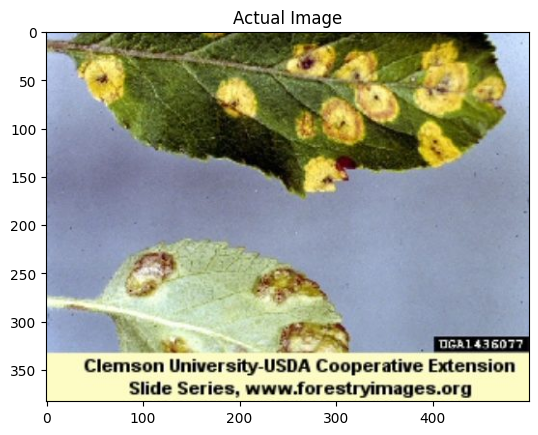

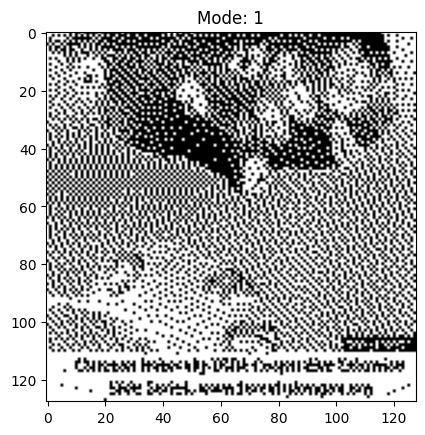

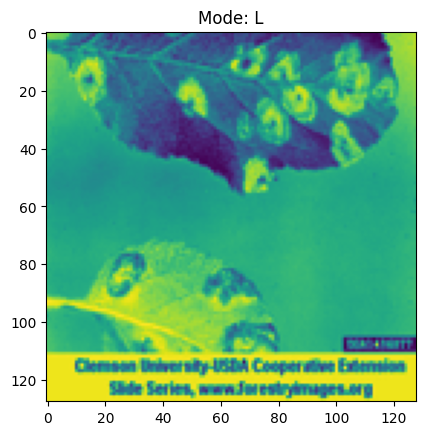

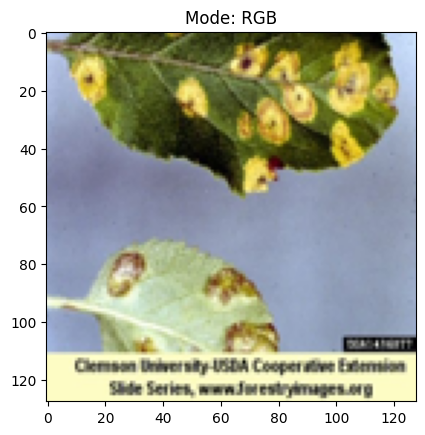

In [52]:
from os import path
import matplotlib.pyplot as plt

image_modes = ['1', 'L', 'RGB']
random_image = path.join("TRAIN", df.iloc[12].filename)

plt.imshow(plt.imread(random_image))
plt.title(f"Actual Image")
plt.show()

for mode in image_modes:
  image = Image.open(random_image).resize((128, 128)).convert(mode)
  plt.imshow(image)
  plt.title(f"Mode: {mode}")
  plt.show()

In [ ]:
import os
import cupy as cp
from PIL import Image
import sys

labels = {name: index for index, name in enumerate(df['class'].unique())}

train_dir = "TRAIN"

x, y = [], []

processed, missing = 0, 0

for row in df.itertuples():
  image_path = os.path.join(train_dir, row.filename)

  if os.path.exists(image_path):
    processed += 1
  else:
    missing += 1
    continue

  if processed % 500 == 0:
    print(f"Processed: {processed} Missing: {missing}")

  image = Image.open(image_path)
  resized_image = image.resize((128, 128)).convert('RGB')
  array = cp.asarray(resized_image, dtype=cp.float32) / 255.0
  flattened_array = array.flatten()
  x.append(flattened_array.get())
  y.append(labels[row._4])

print(f"Total Processed: {processed} Total Missing: {missing}")

Processed: 500 Missing: 8
Processed: 1000 Missing: 8
Processed: 1500 Missing: 8
Processed: 2000 Missing: 8
Processed: 2500 Missing: 8
Processed: 3000 Missing: 8
Processed: 3500 Missing: 8
Processed: 4000 Missing: 8
Processed: 4500 Missing: 8
Processed: 5000 Missing: 8
Processed: 5500 Missing: 8
Processed: 6000 Missing: 8
Processed: 6500 Missing: 8
Processed: 7000 Missing: 8
Processed: 7500 Missing: 8
Processed: 8000 Missing: 8
Total Processed: 8458 Total Missing: 11


In [16]:
x = cp.array(x)
y = cp.array(y)

In [21]:
pd.DataFrame({
    "X": x.shape,
    "Y": y.shape
}, index=['Rows', 'Columns']).T

,Rows,Columns
X,8458,49152
Y,8458,8458


In [22]:
from sklearn.preprocessing import OneHotEncoder

y_np = cp.asnumpy(y)
y_reshaped = y_np.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y_reshaped)

y_encoded = cp.asarray(y_encoded)

In [23]:
from sklearn.model_selection import train_test_split

x_np = cp.asnumpy(x)
y_np = cp.asnumpy(y_encoded)

x_train, x_test, y_train, y_test = train_test_split(x_np, y_np, test_size=0.2, random_state=42)

x_train = cp.asarray(x_train)
x_test = cp.asarray(x_test)
y_train = cp.asarray(y_train)
y_test = cp.asarray(y_test)

In [24]:
class ELM:
  def __init__(self, input_size, hidden_size, output_size):
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

    self.input_weights = cp.random.randn(self.input_size, self.hidden_size)
    self.bias = cp.random.randn(self.hidden_size)

    self.beta = None

  def _activation(self, x):
    return cp.maximum(0, x)

  def train(self, x, y):
    H = self._activation(cp.dot(x, self.input_weights) + self.bias[cp.newaxis, :])
    self.beta = cp.dot(cp.linalg.pinv(H), y)

  def predict(self, x):
    H = self._activation(cp.dot(x, self.input_weights) + self.bias[cp.newaxis, :])
    return cp.dot(H, self.beta)

In [25]:
elm = ELM(x_train.shape[1], 4096, y_train.shape[1])

if os.path.exists("elm_model.npz"):
  loaded = cp.load("elm_model.npz")
  elm.bias = loaded["bias"]
  elm.input_weights = loaded["input_weights"]
  elm.beta = loaded["beta"]
else:
  elm.train(x_train, y_train)

In [55]:
# Takes too much time so maybe skip it for now
cp.savez("elm_model.npz", bias=elm.bias, input_weights=elm.input_weights, beta=elm.beta)

In [26]:
y_pred = elm.predict(x_test)

y_pred_labels = cp.argmax(y_pred, axis=1)
y_true_labels = cp.argmax(y_test, axis=1)

In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(cp.asnumpy(y_true_labels), cp.asnumpy(y_pred_labels))
print(f"Test Accuracy: {accuracy * 100:.2f}%")

elm_accuracy = accuracy

Test Accuracy: 86.88%


In [54]:
from sklearn.metrics import classification_report

print(classification_report(cp.asnumpy(y_true_labels), cp.asnumpy(y_pred_labels)))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        39
           1       1.00      0.99      1.00       120
           2       0.98      0.72      0.83        68
           3       1.00      0.68      0.81        34
           4       0.43      0.82      0.56        40
           5       1.00      0.97      0.98        89
           6       1.00      0.28      0.44        25
           7       0.29      0.65      0.41        43
           8       1.00      0.76      0.86        50
           9       0.52      0.85      0.64        80
          10       1.00      0.82      0.90        56
          11       1.00      1.00      1.00       166
          12       1.00      0.99      1.00       158
          13       1.00      0.98      0.99        41
          14       1.00      0.97      0.98       100
          15       0.93      0.71      0.80        52
          16       1.00      0.68      0.81        41
          17       1.00    

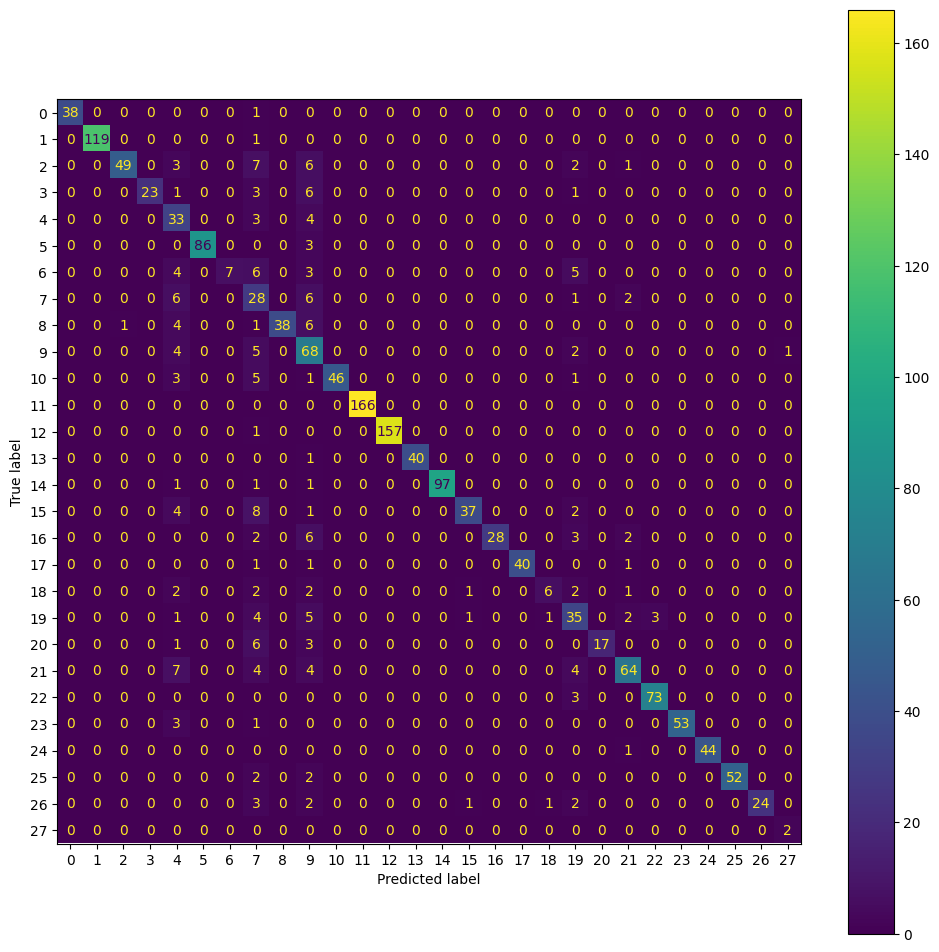

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cn = confusion_matrix(cp.asnumpy(y_true_labels), cp.asnumpy(y_pred_labels))

all_labels = cp.unique(cp.concatenate([y_true_labels, y_pred_labels])).get()

display_labels = [df['class'].unique()[label] for label in all_labels]

disp = ConfusionMatrixDisplay(confusion_matrix=cn)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax)

plt.show()

In [ ]:
# test_pd = pd.read_csv("./train_labels.csv")

# test_pd.head()

In [ ]:
# # Since most of files are missing i am unsure what to do
# test_dir = "TEST"
# u_x_test, u_y_test = [], []

# processed, missing = 0, 0

# for row in test_pd.itertuples():
#   image_path = os.path.join(test_dir, row.filename)

#   if os.path.exists(image_path):
#     processed += 1
#   else:
#     missing += 1
#     continue

#   if processed % 500 == 0:
#     print(f"Processed: {processed} Missing: {missing}")

#   image = Image.open(image_path).convert('RGB')
#   resized_image = image.resize((128, 128))
#   array = cp.asarray(resized_image, dtype=cp.float32) / 255.0
#   flattened_array = array.ravel()
#   u_x_test.append(flattened_array)
#   u_y_test.append(labels[row._4])

# print(f"Total Processed: {processed} Total Missing: {missing}")

In [41]:
# ANN = CNN
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

x_train_torch = torch.tensor(x_train.get()).reshape(-1, 3, 128, 128).float()
x_test_torch = torch.tensor(x_test.get()).reshape(-1, 3, 128, 128).float()

y_train_indices = torch.tensor(cp.argmax(y_train, axis=1).get()).long()
y_test_indices = torch.tensor(cp.argmax(y_test, axis=1).get()).long()

train_ds = TensorDataset(x_train_torch, y_train_indices)
test_ds = TensorDataset(x_test_torch, y_test_indices)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

class TinyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = TinyCNN(num_classes=29).cuda()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.cuda(), yb.cuda()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.cuda(), yb.cuda()
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

cnn_accuracy = accuracy


Epoch 1: Loss = 2.3662
Epoch 2: Loss = 1.7849
Epoch 3: Loss = 0.9951
Epoch 4: Loss = 0.5685
Epoch 5: Loss = 0.5677
Epoch 6: Loss = 0.2853
Epoch 7: Loss = 0.1396
Epoch 8: Loss = 0.1095
Epoch 9: Loss = 0.0729
Epoch 10: Loss = 0.0258
Test Accuracy: 87.17%


In [42]:
# SVM
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import cupy as cp

x_train_np = x_train.get()
x_test_np = x_test.get()
y_train_np = cp.argmax(y_train, axis=1).get()
y_test_np = cp.argmax(y_test, axis=1).get()

pca = PCA(n_components=100)
x_train_pca = pca.fit_transform(x_train_np)
x_test_pca = pca.transform(x_test_np)

clf = SVC(kernel='rbf', C=1.0, gamma='scale')
clf.fit(x_train_pca, y_train_np)

y_pred = clf.predict(x_test_pca)

acc = accuracy_score(y_test_np, y_pred)
print(f"Test Accuracy: {acc * 100:.2f}%")

svm_accuracy = acc

Test Accuracy: 72.75%


In [43]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(x_train_pca, y_train_np)

y_pred_knn = knn.predict(x_test_pca)

acc_knn = accuracy_score(y_test_np, y_pred_knn)
print(f"Test Accuracy: {acc_knn * 100:.2f}%")

knn_accuracy = acc_knn

Test Accuracy: 73.70%


In [47]:
pd.DataFrame({
    "Model": ["ELM", "CNN", "SVM", "KNN"],
    "Accuracy": [elm_accuracy * 100, cnn_accuracy, svm_accuracy * 100, knn_accuracy * 100],
}, index=['', '', '', ''])

,Model,Accuracy
,ELM,86.879433
,CNN,87.174941
,SVM,72.754137
,KNN,73.699764


In [53]:
!du -sh *

55M	sample_data
72M	TEST
36K	test_labels.csv
904M	TRAIN
648K	train_labels.csv


In [56]:
from google.colab import drive

drive.mount('/content/drive')

!mv elm_model.npz /content/drive/MyDrive

Mounted at /content/drive
